In [3]:
#🏠 House Price Prediction using Regression

#Objective:
#The goal of this project is to analyze housing data and build regression models to predict house prices based on features such as area and location.

#Algorithms used:
#Linear Regression, Multiple Linear Regression (using scikit-learn)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [21]:
df = pd.read_excel("../data/house_data.xlsx")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [22]:
df.shape

(20640, 10)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [24]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [25]:
# Checking missing values
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [26]:
# Fill missing values in total_bedrooms with median
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

In [27]:
# Verify
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [29]:
#EDA (Exploratory Data Analysis)

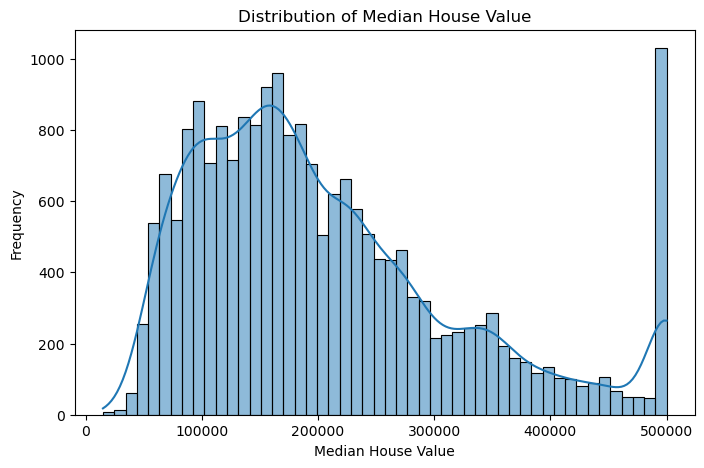

In [30]:
#1️⃣ Distribution of Target Variable
plt.figure(figsize=(8,5))
sns.histplot(df['median_house_value'], bins=50, kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

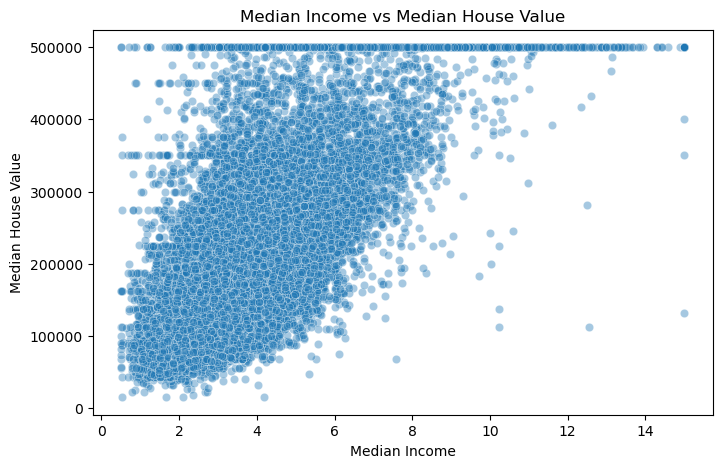

In [31]:
#2️⃣ Median Income vs House Price
plt.figure(figsize=(8,5))
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.4)
plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

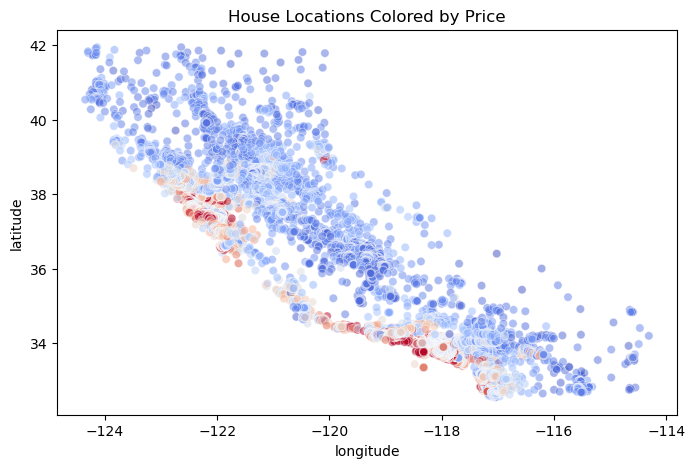

In [32]:
#3️⃣ Location-based Price Distribution
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='longitude',
    y='latitude',
    hue='median_house_value',
    data=df,
    palette='coolwarm',
    alpha=0.5,
    legend=False
)
plt.title("House Locations Colored by Price")
plt.show()

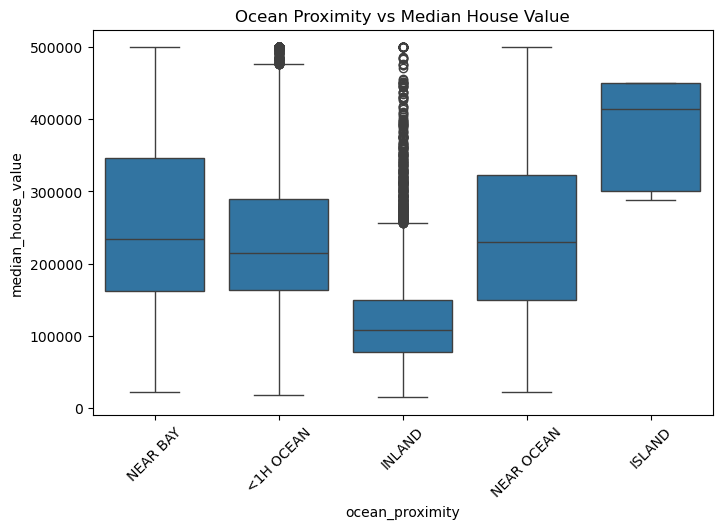

In [33]:
#4️⃣ Ocean Proximity vs House Price
plt.figure(figsize=(8,5))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df)
plt.xticks(rotation=45)
plt.title("Ocean Proximity vs Median House Value")
plt.show()

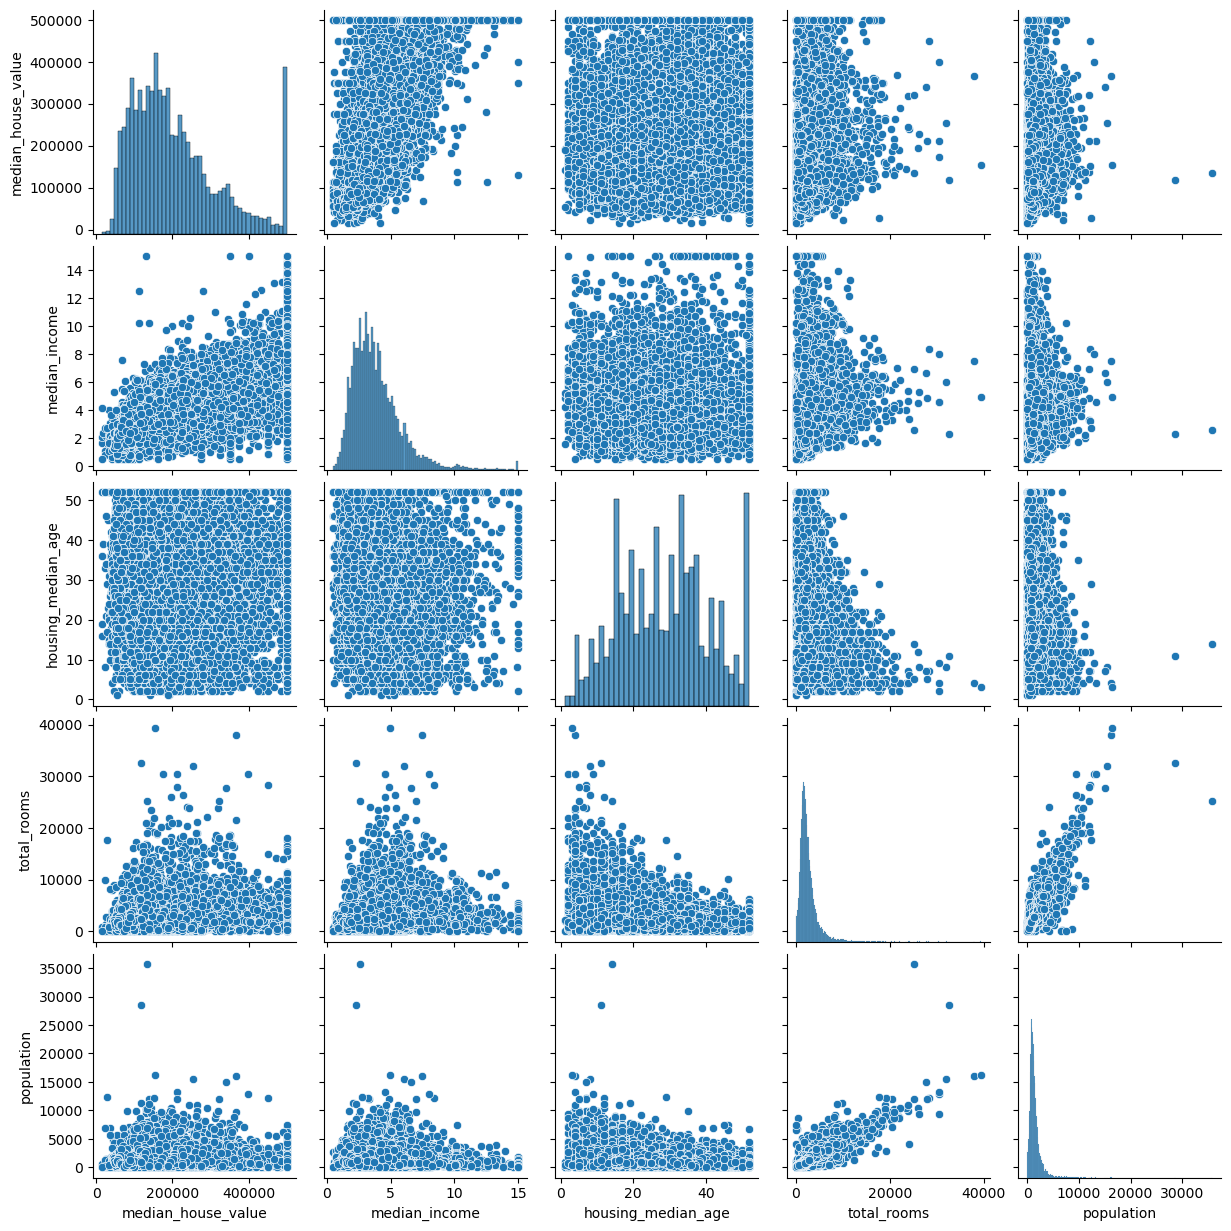

In [36]:
#5️⃣ The pairplot
selected_features = [
    'median_house_value',
    'median_income',
    'housing_median_age',
    'total_rooms',
    'population'
]

sns.pairplot(df[selected_features])
plt.show()

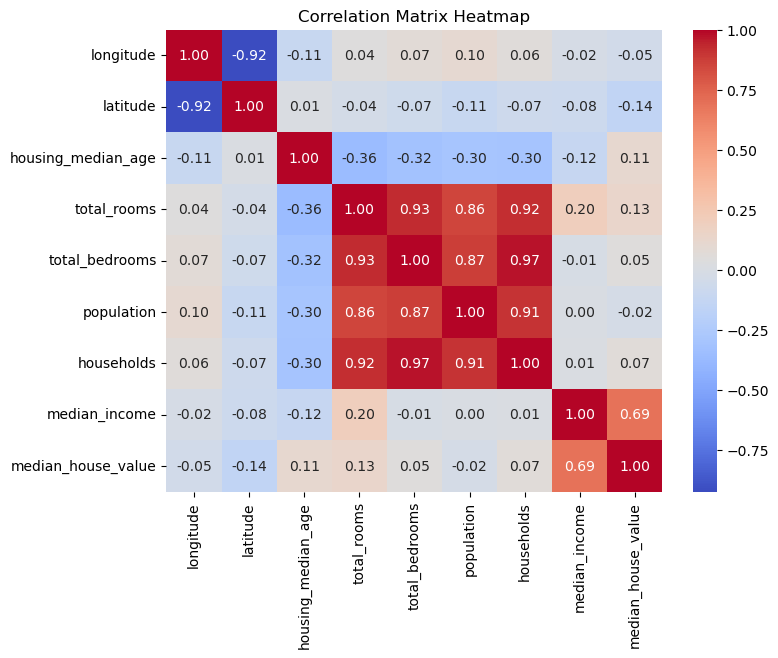

In [39]:
#6️⃣ Correlation Understanding
relation_table=df.corr(numeric_only=True)
# Create a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(relation_table, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [50]:
# Simple Linear Regression
# With 0.69 correlation in median_house_value and median_income
# X = median_income
# y = median_house_value

# Feature and target
X = df[['median_income']]
y = df['median_house_value']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

#Checking Model efficency
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.45885918903846656
MAE: 62990.86530093761
RMSE: 84209.01241414454


In [51]:
#Multiple Linear Regression

features = [
    'median_income',
    'housing_median_age',
    'total_rooms',
    'population',
    'households',
    'latitude',
    'longitude'
]

X = df[features]
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred = mlr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.6205180997418556
MAE: 51657.46516225331
RMSE: 70517.83385627995


In [49]:
#Adding multiple relevant features significantly improved the model performance, increasing the R² score from 0.45 to 0.62 and reducing prediction error.

In [55]:
#Regression Coefficients
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr.coef_
})

coeff_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
0,median_income,38614.279289
1,housing_median_age,1149.014918
4,households,150.053689
2,total_rooms,-1.777396
3,population,-43.054971
6,longitude,-41830.450249
5,latitude,-42125.925477


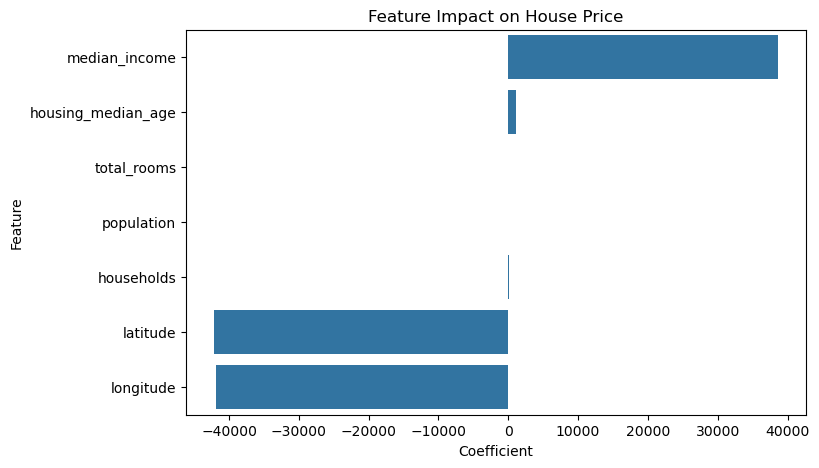

In [56]:
#Coefficient Visualization
plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=coeff_df)
plt.title("Feature Impact on House Price")
plt.show()

In [57]:
#Model Interpretation:
#Median income has the strongest positive influence on house prices, confirming its importance observed during EDA.
#Geographic features such as latitude and longitude also play a major role, highlighting the impact of location.
#Room and population-related features show weaker or negative effects, suggesting that overcrowding may reduce property value.

In [58]:
#Handle Categorical Feature (ocean_proximity)
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [64]:
#Separate Features & Target
X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']
feature_names = X.columns

In [60]:
#Standerdizing Scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [62]:
# Enhanced Multiple Regression Model

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train Model (Enhanced Multiple Regression)
mlr_scaled = LinearRegression()
mlr_scaled.fit(X_train, y_train)

y_pred = mlr_scaled.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.6254240620553606
MAE: 50670.73824097191
RMSE: 70060.52184473518


In [66]:
# Model Use

# Example new house data (same order as training features)
new_house_raw = pd.DataFrame([{
    'longitude': -122.23,
    'latitude': 37.88,
    'housing_median_age': 41,
    'total_rooms': 880,
    'total_bedrooms': 129,
    'population': 322,
    'households': 126,
    'median_income': 8.3252,
    'ocean_proximity': 'NEAR OCEAN'
}])

# Apply same encoding
new_house_encoded = pd.get_dummies(new_house_raw)

# Reindex to match training features
new_house_encoded = new_house_encoded.reindex(columns=feature_names, fill_value=0)

new_house_scaled = scaler.transform(new_house_encoded)

predicted_price = mlr_scaled.predict(new_house_scaled)
print("Predicted House Price:", predicted_price[0])

Predicted House Price: 419152.14159833634


In [ ]:
### Model Usage Example

#The trained regression model can be used to predict house prices for new data by applying the same preprocessing steps, including encoding categorical variables and scaling numerical features. This ensures consistency between training and prediction phases.